## module 3 — garden layout generation

compose: generate a planting plan for a bed — which plants, where, how many. published
generative garden design is pixel-space (pix2pix / FastGAN / SD img2img on ~100 scraped
plans — Senem et al. DLA 2024; Land 2025) with no plant identity. we go structured: a plan
is a set of (species, x, y, spread) tuples, the same object LayoutTransformer / LayoutDM
generate. no planting-plan dataset exists, so we sample one from horticultural rules
(rainer & west layers), and the rules double as metrics. arc: random baseline → rule
generator → layout transformer trained on rule plans → controlnet render. self-contained,
no bvtrain.

In [1]:
import math, random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.facecolor"] = "linen"
DEV

'cuda'

### plant palette

16 ornamentals from the classifier's 4,094-species vocabulary, traits hand-seeded
(the curated trait table in `models/planned.json` replaces this later). layers per
rainer & west: structural anchors, seasonal theme plants, filler, groundcover.

In [2]:
# h = mature height (cm), s = mature spread (cm)
PALETTE = [
    ("Hydrangea macrophylla", "structural",  150, 150, "cornflowerblue"),
    ("Rosa rugosa",           "structural",  150, 120, "palevioletred"),
    ("Buxus sempervirens",    "structural",  120, 100, "darkolivegreen"),
    ("Monarda didyma",        "seasonal",    110,  45, "firebrick"),
    ("Echinacea purpurea",    "seasonal",    100,  45, "mediumorchid"),
    ("Hemerocallis fulva",    "seasonal",     90,  60, "darkorange"),
    ("Rudbeckia hirta",       "seasonal",     90,  40, "gold"),
    ("Achillea millefolium",  "seasonal",     70,  45, "seashell"),
    ("Leucanthemum vulgare",  "seasonal",     60,  40, "white"),
    ("Salvia nemorosa",       "seasonal",     50,  35, "rebeccapurple"),
    ("Alchemilla mollis",     "filler",       40,  50, "yellowgreen"),
    ("Nepeta racemosa",       "filler",       40,  45, "thistle"),
    ("Geranium sanguineum",   "filler",       30,  40, "mediumvioletred"),
    ("Vinca minor",           "groundcover",  10,  60, "slateblue"),
    ("Phlox subulata",        "groundcover",  10,  50, "hotpink"),
    ("Ajuga reptans",         "groundcover",  10,  40, "midnightblue"),
]
PALETTE = [dict(zip(("name", "layer", "h", "s", "color"), p)) for p in PALETTE]
BY_LAYER = {l: [i for i, p in enumerate(PALETTE) if p["layer"] == l]
            for l in ("structural", "seasonal", "filler", "groundcover")}
HMAX = max(p["h"] for p in PALETTE)
pd.DataFrame(PALETTE)

,name,layer,h,s,color
0,Hydrangea macrophylla,structural,150,150,cornflowerblue
1,Rosa rugosa,structural,150,120,palevioletred
2,Buxus sempervirens,structural,120,100,darkolivegreen
3,Monarda didyma,seasonal,110,45,firebrick
4,Echinacea purpurea,seasonal,100,45,mediumorchid
5,Hemerocallis fulva,seasonal,90,60,darkorange
6,Rudbeckia hirta,seasonal,90,40,gold
7,Achillea millefolium,seasonal,70,45,seashell
8,Leucanthemum vulgare,seasonal,60,40,white
9,Salvia nemorosa,seasonal,50,35,rebeccapurple


### rule generator

taller toward the back, odd-count single-species drifts, spacing from mature spread,
groundcover at the front edge. these plans are the training set; the same rules become
the scoring below.

In [3]:
# a plan is [(species idx, x, y, r)] in meters; y=0 is the front edge
def _fits(plan, x, y, r, w, d):
    if not (r * 0.6 < x < w - r * 0.6 and r * 0.4 < y < d - r * 0.4):
        return False
    return all((x - px) ** 2 + (y - py) ** 2 >= (0.75 * (r + pr)) ** 2 for _, px, py, pr in plan)

def _drift(plan, i, n, w, d):
    # n of one species clustered on a random anchor, depth set by height
    p = PALETTE[i]; r = p["s"] / 200
    yc = d * (0.18 + 0.72 * p["h"] / HMAX); xc = random.uniform(r, w - r)
    placed = 0
    for _ in range(n * 25):
        if placed == n: break
        x = random.gauss(xc, r * 2.2); y = random.gauss(yc, max(r, d * 0.06))
        if _fits(plan, x, y, r, w, d):
            plan.append((i, x, y, r)); placed += 1
    if 0 < placed < n:          # keep drifts odd — drop partials
        del plan[-placed:]

def gen_plan(w, d):
    plan, used = [], set()
    def pick(layer):
        pool = [i for i in BY_LAYER[layer] if i not in used] or BY_LAYER[layer]
        i = random.choice(pool); used.add(i); return i
    for _ in range(max(1, round(w / 3))):
        _drift(plan, pick("structural"), 1, w, d)
    for _ in range(round(w * 0.9)):
        _drift(plan, pick(random.choices(("seasonal", "filler"), (0.7, 0.3))[0]),
               random.choice((3, 5, 7)), w, d)
    for _ in range(min(3, round(w / 2))):
        _drift(plan, pick("groundcover"), random.choice((3, 5)), w, d)
    return plan

def rand_bed():
    return round(random.uniform(3.5, 7.5), 1), round(random.uniform(1.8, 3.0), 1)

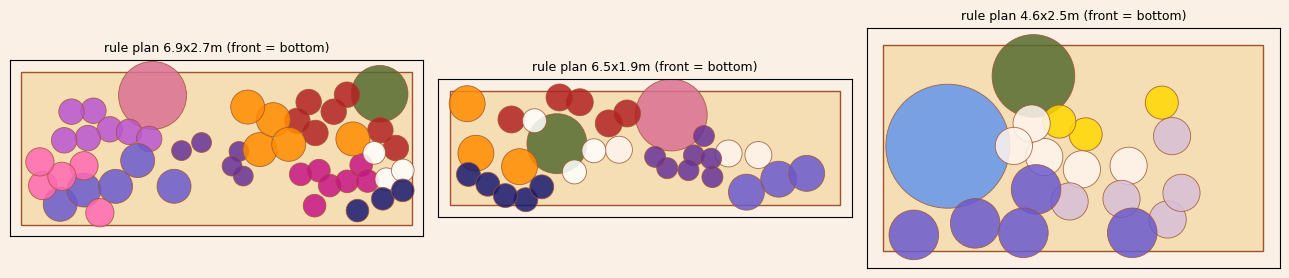

In [4]:
def show_plan(plan, w, d, ax, title=""):
    ax.set_facecolor("linen")
    ax.add_patch(Rectangle((0, 0), w, d, facecolor="wheat", edgecolor="sienna"))
    for i, x, y, r in plan:
        ax.add_patch(Circle((x, y), r, facecolor=PALETTE[i]["color"], edgecolor="sienna",
                            lw=0.6, alpha=0.85))
    ax.set_xlim(-0.2, w + 0.2); ax.set_ylim(-0.2, d + 0.2); ax.set_aspect("equal")
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax in axes:
    w, d = rand_bed()
    show_plan(gen_plan(w, d), w, d, ax, f"rule plan {w}x{d}m (front = bottom)")
plt.tight_layout()

### metrics

every plan — random, rule-made, or model-made — is graded on the same four constraints
(1 = clean): no crowding, no tall-in-front, canopy coverage near 75%, odd drifts.

In [5]:
def m_overlap(plan):
    if len(plan) < 2: return 1.0
    bad = tot = 0
    for a in range(len(plan)):
        for b in range(a + 1, len(plan)):
            _, xa, ya, ra = plan[a]; _, xb, yb, rb = plan[b]
            tot += 1
            if math.hypot(xa - xb, ya - yb) < 0.75 * (ra + rb): bad += 1
    return 1 - bad / tot

def m_height(plan):
    # taller plants shouldn't stand in front of shorter ones in the same corridor
    bad = tot = 0
    for ia, xa, ya, _ in plan:
        for ib, xb, yb, _ in plan:
            if abs(xa - xb) < 1.0 and ya < yb - 0.4:
                tot += 1
                if PALETTE[ia]["h"] > PALETTE[ib]["h"] + 30: bad += 1
    return 1 - bad / tot if tot else 1.0

def m_cover(plan, w, d):
    a = sum(math.pi * r * r for _, _, _, r in plan) / (w * d)
    return max(0.0, 1 - abs(a - 0.75) / 0.75)

def m_drift(plan):
    c = Counter(i for i, _, _, _ in plan if PALETTE[i]["layer"] != "structural")
    if not c: return 0.0
    return sum(1 for n in c.values() if n >= 3 and n % 2 == 1) / len(c)

def score(plan, w, d):
    m = {"overlap": m_overlap(plan), "height": m_height(plan),
         "cover": m_cover(plan, w, d), "drift": m_drift(plan)}
    m["score"] = float(np.mean(list(m.values())))
    return m

### dummy baseline

uniform-random species and positions at a matched plant count — the floor everything
else has to beat.

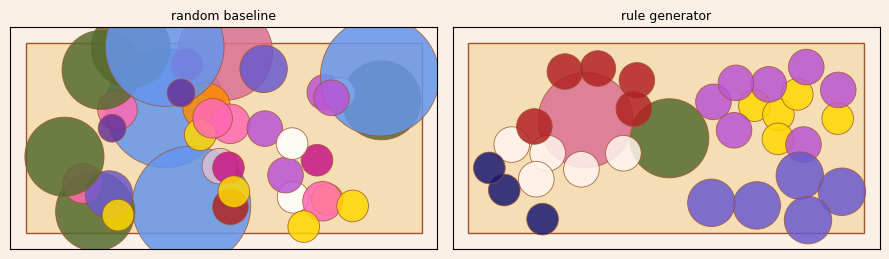

In [6]:
def gen_random(w, d):
    plan = []
    for _ in range(random.randint(20, 40)):
        i = random.randrange(len(PALETTE))
        plan.append((i, random.uniform(0, w), random.uniform(0, d), PALETTE[i]["s"] / 200))
    return plan

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
show_plan(gen_random(5.0, 2.4), 5.0, 2.4, axes[0], "random baseline")
show_plan(gen_plan(5.0, 2.4), 5.0, 2.4, axes[1], "rule generator")
plt.tight_layout()

In [7]:
def eval_gen(fn, n=150):
    rows = []
    for _ in range(n):
        w, d = rand_bed()
        rows.append(score(fn(w, d), w, d))
    return pd.DataFrame(rows).mean().round(3)

results = pd.DataFrame({"random": eval_gen(gen_random), "rules": eval_gen(gen_plan)})
results

,random,rules
overlap,0.949,1.000
height,0.709,0.987
cover,0.630,0.674
drift,0.221,0.997
score,0.627,0.914


### layout transformer

plans become token sequences — bed-size prefix, then (species, x, y) triples on a 32x12
grid, back-to-front — so a small gpt-style decoder (~1M params) can learn the rules from
sampled plans. same family as LayoutTransformer / LayoutDM, scaled to train in minutes
on any gpu (or cpu).

In [8]:
NX, NY, NW, ND = 32, 12, 9, 7          # x/y grid, bed width/depth buckets
PAD, BOS, EOS = 0, 1, 2
T_W  = 3
T_D  = T_W + NW
T_SP = T_D + ND
T_X  = T_SP + len(PALETTE)
T_Y  = T_X + NX
VOCAB = T_Y + NY
MAXP = 60; MAXLEN = 3 + 3 * MAXP + 1

def bed_tokens(w, d):
    return [BOS, T_W + min(NW - 1, int((w - 3.5) / 0.5)), T_D + min(ND - 1, int((d - 1.8) / 0.2))]

def encode(plan, w, d):
    t = bed_tokens(w, d)
    for i, x, y, r in sorted(plan, key=lambda p: (-p[2], p[1]))[:MAXP]:   # back-to-front
        t += [T_SP + i, T_X + min(NX - 1, int(x / w * NX)), T_Y + min(NY - 1, int(y / d * NY))]
    t.append(EOS)
    return t + [PAD] * (MAXLEN - len(t))

def decode(tokens, w, d):
    plan = []
    ts = [t for t in tokens if t >= T_SP]
    for k in range(0, len(ts) - 2, 3):
        s, x, y = ts[k], ts[k + 1], ts[k + 2]
        if not (T_SP <= s < T_X and T_X <= x < T_Y and T_Y <= y < VOCAB): break
        i = s - T_SP
        plan.append((i, (x - T_X + 0.5) / NX * w, (y - T_Y + 0.5) / NY * d, PALETTE[i]["s"] / 200))
    return plan

N_PLANS = 4000
X = torch.tensor([encode(gen_plan(*bd), *bd) for bd in (rand_bed() for _ in range(N_PLANS))])
X.shape

torch.Size([4000, 184])

In [9]:
class LayoutLM(nn.Module):
    def __init__(self, v=VOCAB, dm=128, heads=4, layers=4, ctx=MAXLEN):
        super().__init__()
        self.tok = nn.Embedding(v, dm); self.pos = nn.Embedding(ctx, dm)
        blk = nn.TransformerEncoderLayer(dm, heads, dm * 4, dropout=0.1,
                                         batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(blk, layers, enable_nested_tensor=False)
        self.head = nn.Linear(dm, v)
    def forward(self, x):
        n = x.shape[1]
        h = self.tok(x) + self.pos(torch.arange(n, device=x.device))
        mask = nn.Transformer.generate_square_subsequent_mask(n, device=x.device)
        return self.head(self.tf(h, mask=mask, is_causal=True))

model = LayoutLM().to(DEV)
sum(p.numel() for p in model.parameters())

836943

In [10]:
EPOCHS = 12
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X), batch_size=64, shuffle=True)
model.train()
for ep in range(EPOCHS):
    tot = 0.0
    for (xb,) in loader:
        xb = xb.to(DEV)
        loss = F.cross_entropy(model(xb[:, :-1]).reshape(-1, VOCAB), xb[:, 1:].reshape(-1),
                               ignore_index=PAD)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item()
    print(f"epoch {ep + 1:2d}  loss {tot / len(loader):.3f}")

C:\Users\daniel\anaconda3\lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


epoch  1  loss 3.136


epoch  2  loss 2.169


epoch  3  loss 2.065


epoch  4  loss 2.025


...

epoch  8  loss 1.954


epoch  9  loss 1.945


epoch 10  loss 1.936


epoch 11  loss 1.929


epoch 12  loss 1.921


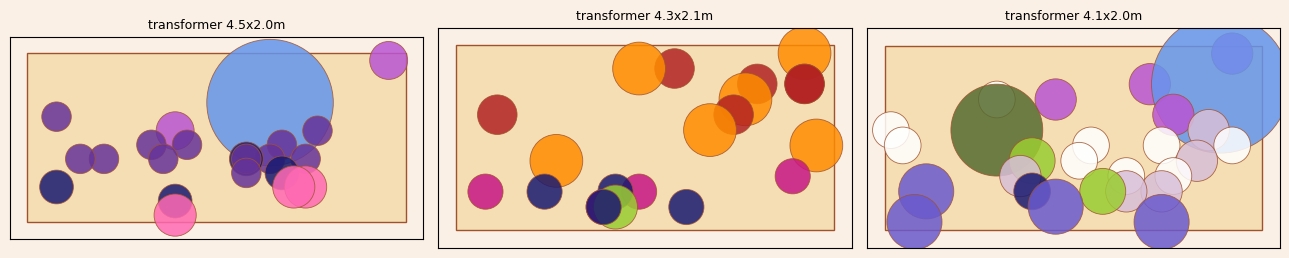

In [11]:
# grammar-constrained sampling: each slot draws only from its own token family
def sample_plan(w, d, temp=0.9):
    model.eval()
    t = bed_tokens(w, d)
    slots = [(T_SP, T_X), (T_X, T_Y), (T_Y, VOCAB)]
    with torch.no_grad():
        for k in range(MAXP * 3):
            logits = model(torch.tensor([t], device=DEV))[0, -1] / temp
            lo, hi = slots[k % 3]
            mask = torch.full_like(logits, float("-inf"))
            mask[lo:hi] = 0
            if k % 3 == 0: mask[EOS] = 0        # may stop before starting a triple
            tok = torch.multinomial(F.softmax(logits + mask, -1), 1).item()
            if tok == EOS: break
            t.append(tok)
    return decode(t, w, d)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax in axes:
    w, d = rand_bed()
    show_plan(sample_plan(w, d), w, d, ax, f"transformer {w}x{d}m")
plt.tight_layout()

,random,rules,transformer
overlap,0.949,1.000,0.957
height,0.709,0.987,0.992
cover,0.630,0.674,0.676
drift,0.221,0.997,0.448
score,0.627,0.914,0.768


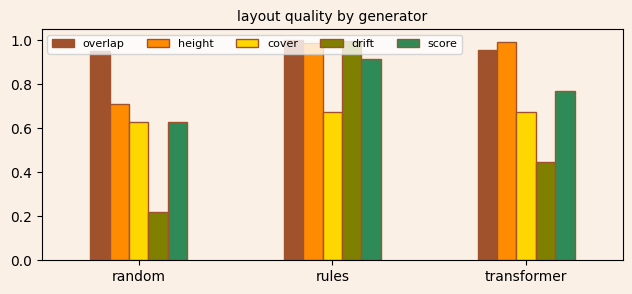

In [12]:
results["transformer"] = eval_gen(sample_plan, n=100)
ax = results.T[["overlap", "height", "cover", "drift", "score"]].plot.bar(
    color=["sienna", "darkorange", "gold", "olive", "seagreen"],
    figsize=(7.5, 3), rot=0, edgecolor="sienna")
ax.set_facecolor("linen"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncols=5); ax.set_title("layout quality by generator", fontsize=10)
results

### render (gated)

a plan is already a segmentation map — colored canopy blobs on a bed — which is exactly
what a seg controlnet conditions on. sd 1.5 + `control_v11p_sd15_seg` + lcm-lora renders
it in 4 steps; needs ~6gb vram, so flip `RUN_RENDER` on colab. the conditioning image
builds anywhere:

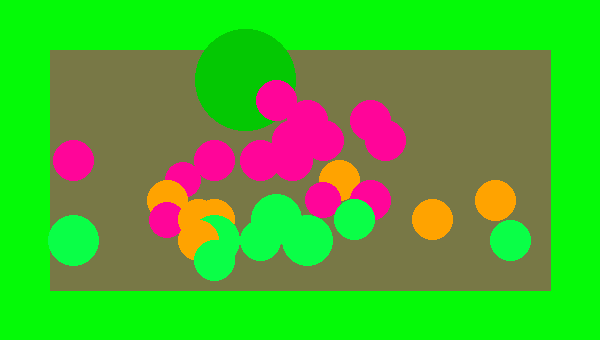

In [13]:
from PIL import Image, ImageDraw

RUN_RENDER = False      # colab t4: pip install diffusers accelerate peft, set True

def seg_image(plan, w, d, px=100, pad=0.5):
    img = Image.new("RGB", (int((w + 2 * pad) * px), int((d + 2 * pad) * px)), (4, 250, 7))  # grass
    dr = ImageDraw.Draw(img)
    dr.rectangle([pad * px, pad * px, (pad + w) * px, (pad + d) * px], fill=(120, 120, 70))  # earth
    lay_col = {"structural": (4, 200, 3), "seasonal": (255, 5, 153),
               "filler": (255, 163, 0), "groundcover": (10, 255, 71)}
    for i, x, y, r in plan:
        cx, cy = (pad + x) * px, (pad + d - y) * px          # image y runs front-down
        dr.ellipse([cx - r * px, cy - r * px, cx + r * px, cy + r * px],
                   fill=lay_col[PALETTE[i]["layer"]])
    return img

cond = seg_image(sample_plan(5.0, 2.4), 5.0, 2.4)
cond

In [14]:
if RUN_RENDER:
    from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, LCMScheduler
    cn = ControlNetModel.from_pretrained("lllyasviel/control_v11p_sd15_seg", torch_dtype=torch.float16)
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5", controlnet=cn,
        torch_dtype=torch.float16, safety_checker=None).to("cuda")
    pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
    pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
    out = pipe("top-down garden planting plan, perennial border with shrubs, lush, "
               "watercolor botanical illustration",
               image=cond, num_inference_steps=4, guidance_scale=1.5,
               controlnet_conditioning_scale=0.9).images[0]
    display(out)

### takeaways

- one scale for everything: random 0.63 < transformer 0.77 < rules 0.91. the model learns
  height banding (0.99), spacing, and coverage from tokens alone — without ever seeing the
  scoring code — but misses odd-count drifts (0.45), a global discrete constraint that
  next-token sampling can't count its way through.
- next: layoutdm-style masked/discrete diffusion for constraint completion (fix the
  shrubs, infill the rest — and a natural fix for the drift miss), the curated trait table
  (`models/planned.json`), a module-2 style lora on the render, and wiring plans into the
  demo's compose tab.